# Query understanding for semantic search on Qdrant: Jev and confidence-gated filters on long shopping queries

> *"I need something that can entertain my kids during bath time. It should be able to get messy, like smearing peanut butter on it."*

Shoppers who write like this never name the department. Hybrid search (dense + BM25) matches words such as "kids", "bath" and "peanut butter", and products from the wrong department compete for the top spots.

`jevqu` asks Jev, TypeSafe's decision model, which department the query is about, then lets Jev's confidence decide what happens in Qdrant:

| confidence P | what jevqu does |
|---|---|
| P ≥ 0.9 | hard payload filter; if too few hits come back, the page is refilled from the unfiltered ranking |
| 0.6 ≤ P < 0.9 | score boost through a Qdrant formula query |
| P < 0.6 | nothing: results are identical to plain hybrid search |

The notebook answers four questions on **Amazon-C4**:

1. Does gated query understanding beat plain hybrid search on nDCG@10, and how much of the possible gain does it capture?
2. How much does a hard filter cost when the guess is wrong, and does gating avoid that cost?
3. Where should the filter threshold sit for this collection?
4. How does it compare with Netflix's approach to query understanding for semantic search, which routes each query to a trie, a compact BERT model or an LLM?

## Why Amazon-C4

[Amazon-C4](https://huggingface.co/datasets/McAuley-Lab/Amazon-C4) (McAuley Lab, from the [BLaIR paper](https://arxiv.org/abs/2403.03952)) has 21,223 long product-search queries. ChatGPT wrote each one from a real Amazon review, and the reviewed item is the single correct answer. The item pool has about 1M products in 31 departments.

Before building anything, we checked the headroom: how much would nDCG@10 improve if every query were filtered to its target item's department? On 300 queries and a 20k-item collection, **+10.1 points** (95% CI +7.7 to +12.8), from a weak hybrid baseline of 0.30. The same check on WANDS, a short-query benchmark, allowed only about +3.5, because its three-word queries rarely confuse departments. Query understanding pays off where queries are long and the intent is implied; Netflix saw the same, with long natural-language searches that used to dead-end.

Caveats: the queries are machine-written, each has exactly one correct item, and 31 departments is a coarse taxonomy.

## Which classifier runs

- **With `OPENROUTER_API_KEY` set** (in the environment or in a `.env` file at the repo root), Jev (`typesafe/jev-1.13`) classifies every item and every query through OpenRouter's System One endpoint. Jev is a decision model, not a chat model: each request is one state plus all 31 department questions, judged together, and the answer is a probability per question, back in about half a second. Only input tokens are billed. The notebook labels a small pilot batch first, reads the cost from each response, and stops if the extrapolated total exceeds `JEVQU_MAX_USD` (default $10). Answers are cached in `.jev_cache/`, so reruns cost nothing.
- **Without a key**, a simulated classifier stands in so the notebook runs offline. Items get their catalog department, with 2% relabeled at random. Queries get a calibrated guess: confidence P is drawn uniformly from [0.5, 1], and the guess is right with probability P. The simulation picks its confidence without reading the query, so it says how the gating behaves for a classifier of known quality, not how good Jev is.

Calibration does not transfer across collections, so section 7 checks it on this one before the thresholds are trusted.

In [7]:
import csv, dataclasses, json, os, random, re, sys, tempfile, time, urllib.request, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")        # tqdm without ipywidgets
warnings.filterwarnings("ignore", message="Payload indexes have no effect")  # in-memory Qdrant only

import matplotlib.pyplot as plt
import numpy as np
from fastembed import SparseTextEmbedding, TextEmbedding
from IPython.display import Markdown, display
from qdrant_client import QdrantClient, models
from sklearn.linear_model import LogisticRegression

ROOT = Path.cwd() if (Path.cwd() / "jevqu").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
for line in (ROOT / ".env").read_text().splitlines() if (ROOT / ".env").exists() else []:
    key, _, value = line.partition("=")
    if key.strip() and not key.lstrip().startswith("#"):
        os.environ.setdefault(key.strip(), value.strip().strip("'\""))

from jevqu import JEV_MODEL
from jevqu.api import create_query_understanding, set_query_understanding, understand_query, upload_points
from jevqu.evalstark import recall_loss_curve, report_markdown
from jevqu.jev import Jev
from jevqu.metrics import ndcg_at_k, paired_bootstrap, recall_at_k
from jevqu.qquery import build_filter, build_formula, run
from jevqu.schema import ClassDef, Taxonomy, Thresholds, Understanding
from jevqu.store import load_taxonomy

SEED = 0
N_QUERIES = 300           # evaluation queries (of Amazon-C4's 21,223)
N_POINTS = 20_000         # collection: each query's target item plus a uniform sample of the 1M-item pool
CONF_LOW = 0.5            # simulated classifier only: confidence ~ U(CONF_LOW, 1)
USE_JEV = bool(os.environ.get("OPENROUTER_API_KEY"))
MAX_USD = float(os.environ.get("JEVQU_MAX_USD", "10"))  # labeling stops before spending more than this
WORKERS = 8               # parallel Jev requests (stays under Jev's ~1,200 requests a minute)
PILOT = 25                # items labeled first to price the full run
DATA = ROOT / "data" / "c4"
COLLECTION = "c4"
CLASSIFIER = JEV_MODEL if USE_JEV else "simulated"
ADV = "Jev" if USE_JEV else "simulated classifier"   # the classifier behind jevqu in this run
print("classifier:", f"Jev ({JEV_MODEL}) on OpenRouter" if USE_JEV else "simulated (no OPENROUTER_API_KEY)")

classifier: Jev (typesafe/jev-1.13) on OpenRouter


## 1. Load Amazon-C4

The queries (12 MB) and the 1M-item pool (about 640 MB) download into `data/c4/` on the first run. The pool is streamed: the notebook keeps each sampled query's target item plus a uniform random sample of the rest.

In [8]:
BASE = "https://huggingface.co/datasets/McAuley-Lab/Amazon-C4/resolve/main/"
DATA.mkdir(parents=True, exist_ok=True)
csv.field_size_limit(sys.maxsize)
for local, remote in [("test.csv", "test.csv"), ("items.jsonl", "sampled_item_metadata_1M.jsonl")]:
    if not (DATA / local).exists():
        urllib.request.urlretrieve(BASE + remote, DATA / local)

rng = random.Random(SEED)
with open(DATA / "test.csv", newline="") as f:
    rows = list(csv.DictReader(f))
evalq = rng.sample(rows, N_QUERIES)
targets = {q["item_id"] for q in evalq}
items, pool, seen = {}, [], 0
with open(DATA / "items.jsonl") as f:
    for line in f:
        d = json.loads(line)
        if d["item_id"] in targets:
            items[d["item_id"]] = d
            continue
        seen += 1
        if len(pool) < N_POINTS:
            pool.append(d)
        elif (j := rng.randrange(seen)) < N_POINTS:
            pool[j] = d
for d in pool[: N_POINTS - len(items)]:
    items[d["item_id"]] = d
catalog = list(items.values())
pid = {d["item_id"]: n for n, d in enumerate(catalog)}
qtexts = [q["query"] for q in evalq]
relevant = [{pid[q["item_id"]]} for q in evalq]
print(f"{len(rows):,} queries in Amazon-C4, {len(evalq)} sampled (median {int(np.median([len(q.split()) for q in qtexts]))} "
      f"words); {len(catalog):,} items in the collection")

21,223 queries in Amazon-C4, 300 sampled (median 35 words); 20,000 items in the collection


## 2. A taxonomy from the departments

C4 stores a one-word department per item ("Care", "Household", "Cell"). Each one abbreviates an Amazon Reviews 2023 category; the expansion below is our reading of those names. A bare name is too vague to classify against, so each definition also lists three example product titles from the collection.

In [9]:
DEPARTMENTS = {
    "Appliances": "Appliances", "Arts": "Arts, Crafts and Sewing", "Automotive": "Automotive",
    "Baby": "Baby Products", "Beauty": "All Beauty", "Books": "Books", "CDs": "CDs and Vinyl",
    "Care": "Beauty and Personal Care", "Cell": "Cell Phones and Accessories",
    "Clothing": "Clothing, Shoes and Jewelry", "Electronics": "Electronics", "Fashion": "Amazon Fashion",
    "Food": "Grocery and Gourmet Food", "Games": "Video Games", "Garden": "Patio, Lawn and Garden",
    "Gift": "Gift Cards", "Handmade": "Handmade Products", "Health": "Health and Personal Care",
    "Home": "Home and Kitchen", "Household": "Health and Household", "Instruments": "Musical Instruments",
    "Kindle": "Kindle Store", "Magazine": "Magazine Subscriptions", "Movies": "Movies and TV",
    "Office": "Office Products", "Pet": "Pet Supplies", "Scientific": "Industrial and Scientific",
    "Software": "Software", "Sports": "Sports and Outdoors", "Toys": "Toys and Games",
    "Tools": "Tools and Home Improvement"}

def slug(s):
    return re.sub(r"[^a-z0-9]+", "-", s.lower()).strip("-")

def title(d):
    return d["metadata"].split(". ")[0][:80]

examples = defaultdict(list)
for d in catalog:
    examples[d["category"]].append(title(d))
classes = [ClassDef(slug(c), DEPARTMENTS.get(c, c),
                    f"The product belongs in Amazon's '{DEPARTMENTS.get(c, c)}' department, for example: "
                    + "; ".join(examples[c][:3]), "Products from any other department") for c in sorted(examples)]
tax = Taxonomy("c4-departments-v1", CLASSIFIER, classes, facets=[], thresholds=Thresholds())
label_of = {slug(c): DEPARTMENTS.get(c, c) for c in examples}
gold = {d["item_id"]: slug(d["category"]) for d in catalog}

def intent(i):  # the department of query i's target item
    return gold[evalq[i]["item_id"]]

print(f"{len(classes)} departments; e.g. {classes[0].name}: {classes[0].definition[:150]}...")

31 departments; e.g. Appliances: The product belongs in Amazon's 'Appliances' department, for example: Silonn Countertop Ice Maker Machine, Portable Ice Makers Countertop with Handle,...


## 3. Embed and index

Dense `BAAI/bge-small-en-v1.5` plus sparse BM25 (`Qdrant/bm25`), both through FastEmbed. Dense embeddings are cached in `data/c4/`; the first run takes about five minutes on a laptop CPU.

The payload holds only the item text. The department is deliberately left out: jevqu labels items from their text. The notebook uses in-memory Qdrant; set `QDRANT_URL` to run against a server.

In [10]:
def text(d):
    return d["metadata"][:600]

def sparse_vec(s):
    return models.SparseVector(indices=s.indices.tolist(), values=s.values.tolist())

dense, bm25 = TextEmbedding("BAAI/bge-small-en-v1.5"), SparseTextEmbedding("Qdrant/bm25")
cache = DATA / f"dense_{SEED}_{N_QUERIES}_{N_POINTS}.npy"
if cache.exists():
    dvecs = np.load(cache)
else:
    dvecs = np.array(list(dense.embed([text(d) for d in catalog], batch_size=64)))
    np.save(cache, dvecs)
svecs = list(bm25.embed([text(d) for d in catalog]))

client = QdrantClient(url=os.environ["QDRANT_URL"]) if os.environ.get("QDRANT_URL") else QdrantClient(":memory:")
if client.collection_exists(COLLECTION):
    client.delete_collection(COLLECTION)
client.create_collection(COLLECTION,
    vectors_config={"dense": models.VectorParams(size=dvecs.shape[1], distance=models.Distance.COSINE)},
    sparse_vectors_config={"sparse": models.SparseVectorParams(modifier=models.Modifier.IDF)})
points = [models.PointStruct(id=pid[d["item_id"]], vector={"dense": v.tolist(), "sparse": sparse_vec(s)},
                             payload={"item_id": d["item_id"], "text": text(d)})
          for d, v, s in zip(catalog, dvecs, svecs)]
print(f"{len(points):,} points ready, dense dim {dvecs.shape[1]}")

20,000 points ready, dense dim 384


## 4. The classifier

`SimulatedClassifier` answers the same `ask(state, questions)` calls as the Jev client, so everything downstream (labeling, understanding, filters, boosts, fallback) is jevqu's real code path.

In [11]:
class SimulatedClassifier:
    # Offline stand-in for Jev with the same ask() contract.
    # Items: their catalog department, 2% relabeled at random.
    # Queries: confidence P ~ U(conf_low, 1), and the guess is right with probability P.
    model = "simulated"

    def __init__(self, conf_low=CONF_LOW, seed=SEED):
        rng = random.Random(seed)
        depts = [c.id for c in tax.level1()]
        self.items = {}
        for d in catalog:
            g = gold[d["item_id"]] if rng.random() >= 0.02 else rng.choice(depts)
            self.items[d["item_id"]] = {g: 0.97}
        self.queries = {}
        for i, q in enumerate(evalq):
            p = rng.uniform(conf_low, 1)
            a = intent(i) if rng.random() < p else rng.choice([x for x in depts if x != intent(i)])
            self.queries[q["query"][:1500]] = {a: p}

    def ask(self, state, questions):
        probs = self.queries[state["query"]] if "query" in state else self.items.get(state.get("item_id"), {})
        return {qid: {"type": "noul", "noul": probs.get(qid, 0.02)} for qid in questions}

classifier = Jev(cache_dir=ROOT / ".jev_cache") if USE_JEV else SimulatedClassifier()

## 5. Label the collection

Three of jevqu's public calls: store the taxonomy (and the `classes` payload index), then upsert the items and label each one. Labels land in the payload as `classes`, `class_probs`, `class_model` and `needs_review`. An item whose text tries to instruct the classifier is flagged `needs_review` and gets no classes.

In [12]:
set_query_understanding(client, COLLECTION, tax)
if USE_JEV:  # price a pilot batch before labeling everything
    pilot = points[:PILOT]
    upload_points(client, COLLECTION, pilot, classifier, workers=WORKERS)
    estimate = sum(classifier.usage) / len(pilot) * len(points)
    print(f"pilot of {len(pilot)} items: about ${estimate:.2f} to label all {len(points):,}")
    assert estimate <= MAX_USD, f"estimate is above JEVQU_MAX_USD=${MAX_USD:.0f}: raise it or lower N_POINTS"
t0 = time.time()
failed = upload_points(client, COLLECTION, points, classifier, workers=WORKERS)
print(f"labeled {len(points) - len(failed):,} items in {time.time() - t0:.0f}s, {len(failed)} failed")
if USE_JEV and classifier.usage:
    print(f"spent ${sum(classifier.usage):.4f} on {len(classifier.usage):,} Jev requests")
stored = {pt.id: pt.payload for pt in client.scroll(COLLECTION, limit=len(points), with_payload=["classes", "class_probs"])[0]}
agree = np.mean([gold[d["item_id"]] in (stored[pid[d["item_id"]]].get("classes") or []) for d in catalog])
print(f"items whose label includes their catalog department: {agree:.1%}")

pilot of 25 items: about $0.00 to label all 20,000
labeled 20,000 items in 190s, 0 failed
spent $0.6817 on 4,000 Jev requests
items whose label includes their catalog department: 84.9%


## 6. Understand the queries

One packed request per query with all 31 department questions. `understand_query` refuses to run if the stored labels came from another model or an older taxonomy. Below: one query the classifier leaves alone and one it is sure enough to filter.

In [13]:
tax = load_taxonomy(client, COLLECTION)
def understand_all(clf):  # one request per query, WORKERS at a time
    with ThreadPoolExecutor(WORKERS) as ex:
        return list(ex.map(lambda q: understand_query(client, COLLECTION, q, clf), qtexts))

t0 = time.time()
us = understand_all(classifier)
qd = [d.tolist() for d in dense.embed(qtexts)]
qs = [sparse_vec(s) for s in bm25.embed(qtexts)]
print(f"understood {len(us)} queries in {time.time() - t0:.0f}s")

def top_class(u):
    return max(u.classes, key=lambda kv: kv[1])

def explain(i, u=None):
    u, t = u or us[i], tax.thresholds
    print(f'"{qtexts[i][:120]}{"..." if len(qtexts[i]) > 120 else ""}"')
    print(f"   target item's department: {label_of[intent(i)]}")
    for cid, p in sorted(u.classes, key=lambda kv: -kv[1])[:3]:
        action = "filter" if p >= t.filter_above else "boost" if p >= t.boost_above else "ignore"
        print(f"   P={p:.2f}  {action:6}  {label_of[cid]}")
    flt, fq = build_filter(u, tax, "auto"), build_formula(u, tax, "auto")
    print("   Qdrant filter:", [c.match.value for c in flt.must] if flt else None)
    print("   formula boost:", [(e.mult[1].match.value, round(e.mult[0], 4)) for e in fq.formula.sum[1:]] if fq else None)

explain(next((i for i, u in enumerate(us) if top_class(u)[1] < tax.thresholds.boost_above), 0))
explain(next((i for i, u in enumerate(us) if top_class(u)[1] >= tax.thresholds.filter_above), 0))

understood 300 queries in 32s
"Looking for a tool to use in my math classroom that can help me demonstrate problem-solving to my students on their work..."
   target item's department: Electronics
   P=0.58  ignore  Electronics
   P=0.42  ignore  Office Products
   P=0.33  ignore  Software
   Qdrant filter: None
   formula boost: None
"I am searching for a perfect gift for a teen or tween girl between the ages of 8-14. I want a self-care gift that comes ..."
   target item's department: Beauty and Personal Care
   P=0.90  filter  Beauty and Personal Care
   P=0.78  boost   All Beauty
   P=0.74  boost   Health and Personal Care
   Qdrant filter: ['care']
   formula boost: [('beauty', 0.0078), ('health', 0.0074)]


### Is the classifier calibrated on this collection?

Gating only works if P means what it says. For each query's top guess, how often is it the target item's department within each confidence band?

In [14]:
guesses = [(top_class(u), intent(i)) for i, u in enumerate(us)]
rows = ["| confidence of top guess | queries | right |", "|---|---|---|"]
for lo, hi in [(0, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 1.01)]:
    band = [cid == g for (cid, p), g in guesses if lo <= p < hi]
    if band:
        rows.append(f"| {lo:.1f} to {min(hi, 1):.1f} | {len(band)} | {np.mean(band):.0%} |")
display(Markdown("\n".join(rows)))

| confidence of top guess | queries | right |
|---|---|---|
| 0.0 to 0.5 | 28 | 29% |
| 0.5 to 0.6 | 16 | 62% |
| 0.6 to 0.7 | 17 | 35% |
| 0.7 to 0.8 | 27 | 52% |
| 0.8 to 0.9 | 57 | 54% |
| 0.9 to 1.0 | 155 | 79% |

## 7. Does it help?

Four strategies on the same queries and the same hybrid (dense + BM25, RRF) search:

- **hybrid search**: the baseline, no understanding;
- **filter every guess**: a hard filter on every department the classifier gives P ≥ 0.5;
- **jevqu auto**: filter at P ≥ 0.9, boost at 0.6 ≤ P < 0.9, nothing below;
- **perfect department filter**: every query filtered to its target item's department. Nobody can build this; it is the ceiling.

The 95% interval on the nDCG@10 change is a paired bootstrap over queries. With one correct item per query, recall@20 is the share of queries whose item makes the first page of 20. The ceiling filters on the labels stored in the collection, so it also reflects labeling quality.

In [15]:
BASE, NAIVE, AUTO, ORACLE = "hybrid search", "filter every guess", "jevqu auto", "perfect department filter (ceiling)"

def ranked(mode, thresholds=Thresholds(), understood=None):
    t = dataclasses.replace(tax, thresholds=thresholds)
    return [[h.id for h in run(client, COLLECTION, d, s, None if mode == "off" else u, t, limit=20, mode=mode)]
            for d, s, u in zip(qd, qs, understood or us)]

def scores(r):
    return ([ndcg_at_k(x, rel, 10) for x, rel in zip(r, relevant)],
            [recall_at_k(x, rel, 20) for x, rel in zip(r, relevant)])

oracle_us = [Understanding([(intent(i), 1.0)], {}, tax.version) for i in range(len(evalq))]
runs = {BASE: ranked("off"), NAIVE: ranked("filter", Thresholds(filter_above=0.5)), AUTO: ranked("auto"),
        ORACLE: ranked("filter", understood=oracle_us)}
base_ndcg, base_rec = scores(runs[BASE])
rows = ["| strategy | nDCG@10 | change (95% CI) | recall@20 | queries changed |", "|---|---|---|---|---|"]
for name, r in runs.items():
    nd, rc = scores(r)
    d, lo, hi = paired_bootstrap(base_ndcg, nd)
    changed = np.mean([a != b for a, b in zip(r, runs[BASE])])
    rows.append(f"| {name} | {np.mean(nd):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc):.4f} | {changed:.0%} |")
display(Markdown("\n".join(rows)))
gain = {name: np.mean(scores(r)[0]) - np.mean(base_ndcg) for name, r in runs.items()}
print(f"jevqu auto captured {gain[AUTO] / gain[ORACLE]:.0%} of the ceiling's gain")

| strategy | nDCG@10 | change (95% CI) | recall@20 | queries changed |
|---|---|---|---|---|
| hybrid search | 0.2957 | +0.0000 (+0.0000 to +0.0000) | 0.5333 | 0% |
| filter every guess | 0.3349 | +0.0392 (+0.0225 to +0.0555) | 0.5667 | 89% |
| jevqu auto | 0.3084 | +0.0127 (+0.0048 to +0.0212) | 0.5633 | 84% |
| perfect department filter (ceiling) | 0.3282 | +0.0324 (+0.0102 to +0.0548) | 0.5500 | 100% |

jevqu auto captured 39% of the ceiling's gain


### Where the threshold should sit

Sweep the filter threshold with jevqu's auto mode. At the left end every guess becomes a hard filter; at the right end almost nothing is filtered and the unsure guesses are only boosted. "recall lost" is recall@20 given up against the baseline.

In [16]:
THRESHOLDS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
curve = recall_loss_curve({"off": runs[BASE]}, relevant, THRESHOLDS,
                          lambda t: ranked("auto", Thresholds(filter_above=t)))
display(Markdown(report_markdown(curve, float(np.mean(base_ndcg)))))

Unfiltered hybrid nDCG@10: 0.2957

| threshold | nDCG@10 | nDCG gained | recall@20 | recall lost | queries changed |
|---|---|---|---|---|---|
| 0.5 | 0.3349 | +0.0392 | 0.5667 | 0.0000 | 88.7% |
| 0.6 | 0.3309 | +0.0351 | 0.5667 | 0.0000 | 84.3% |
| 0.7 | 0.3235 | +0.0278 | 0.5600 | 0.0000 | 84.3% |
| 0.8 | 0.3174 | +0.0216 | 0.5567 | 0.0000 | 84.3% |
| 0.9 | 0.3084 | +0.0127 | 0.5633 | 0.0000 | 84.3% |
| 0.95 | 0.3055 | +0.0098 | 0.5567 | 0.0000 | 84.0% |
| 0.99 | 0.2994 | +0.0037 | 0.5433 | 0.0000 | 82.7% |

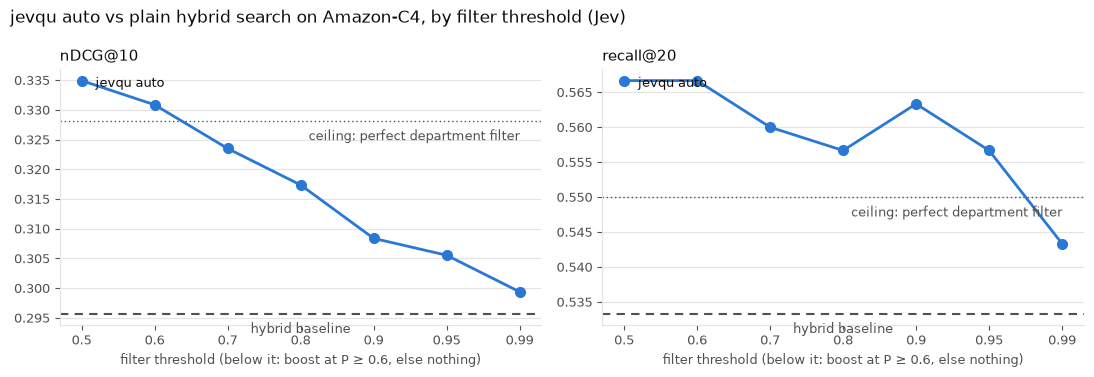

In [17]:
BLUE, INK, MUTED, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df"
ceiling = {"ndcg10": np.mean(scores(runs[ORACLE])[0]), "recall20": np.mean(scores(runs[ORACLE])[1])}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, key, base, title_ in [(axes[0], "ndcg10", np.mean(base_ndcg), "nDCG@10"),
                              (axes[1], "recall20", np.mean(base_rec), "recall@20")]:
    ys = [r[key] for r in curve]
    xs = range(len(THRESHOLDS))
    ax.axhline(base, color=MUTED, lw=1.5, ls=(0, (4, 3)))
    ax.axhline(ceiling[key], color=MUTED, lw=1, ls=(0, (1, 2)))
    ax.plot(xs, ys, color=BLUE, lw=2, marker="o", ms=7)
    ax.annotate("hybrid baseline", (3, base), xytext=(0, -14), textcoords="offset points",
                ha="center", color=MUTED, fontsize=9)
    ax.annotate("ceiling: perfect department filter", (len(xs) - 1, ceiling[key]), xytext=(0, -14),
                textcoords="offset points", ha="right", color=MUTED, fontsize=9)
    ax.annotate("jevqu auto", (0, ys[0]), xytext=(10, -2), textcoords="offset points", va="center", color=INK, fontsize=9)
    ax.set_title(title_, loc="left", color=INK, fontsize=11)
    ax.set_xlabel("filter threshold (below it: boost at P ≥ 0.6, else nothing)", color=MUTED, fontsize=9)
    ax.set_xticks(list(xs), [str(t) for t in THRESHOLDS])
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
fig.suptitle(f"jevqu auto vs plain hybrid search on Amazon-C4, by filter threshold ({ADV})", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

### How large should the boost be?

Boost-only mode (no filters) with three values of `boost_scale`. RRF-fused scores are small and close together, so a small boost moves little. Like the thresholds, this is a per-collection setting to fit, not a constant. The last line combines the sweep's best filter threshold with the largest boost; both are tuned on the evaluation queries themselves, so treat it as optimistic.

In [18]:
rows = ["| boost_scale | nDCG@10 | change vs baseline | queries changed |", "|---|---|---|---|"]
for s in (0.01, 0.05, 0.2):
    r = ranked("boost", Thresholds(boost_scale=s))
    nd, _ = scores(r)
    changed = np.mean([a != b for a, b in zip(r, runs[BASE])])
    rows.append(f"| {s} | {np.mean(nd):.4f} | {np.mean(nd) - np.mean(base_ndcg):+.4f} | {changed:.0%} |")
display(Markdown("\n".join(rows)))

best_t = max(curve, key=lambda r: r["ndcg10"])["threshold"]
tuned = scores(ranked("auto", Thresholds(filter_above=best_t, boost_scale=0.2)))[0]
tuned_ci = paired_bootstrap(base_ndcg, tuned)
print(f"jevqu auto with filter at {best_t} and boost_scale 0.2: nDCG@10 {np.mean(tuned):.4f}, "
      f"change {tuned_ci[0]:+.4f} (95% CI {tuned_ci[1]:+.4f} to {tuned_ci[2]:+.4f})")

| boost_scale | nDCG@10 | change vs baseline | queries changed |
|---|---|---|---|
| 0.01 | 0.2980 | +0.0023 | 82% |
| 0.05 | 0.3022 | +0.0065 | 84% |
| 0.2 | 0.3159 | +0.0202 | 84% |

jevqu auto with filter at 0.5 and boost_scale 0.2: nDCG@10 0.3349, change +0.0392 (95% CI +0.0225 to +0.0555)


## 8. What decides whether a filter pays off

### Right filters and wrong filters

Split the queries by what jevqu's filter did: no filter, a filter on the target item's department, or a filter on a wrong one.

In [19]:
auto_nd = scores(runs[AUTO])[0]
groups = defaultdict(list)
for i, u in enumerate(us):
    f = build_filter(u, tax, "auto")
    groups["no filter" if f is None else "filter on the right department"
           if all(c.match.value == intent(i) for c in f.must) else "filter on a wrong department"].append(i)
rows = ["| queries | count | hybrid search | with jevqu | change |", "|---|---|---|---|---|"]
for name in ["filter on the right department", "filter on a wrong department", "no filter"]:
    idx = groups.get(name, [])
    if idx:
        b, f = np.mean([base_ndcg[i] for i in idx]), np.mean([auto_nd[i] for i in idx])
        rows.append(f"| {name} | {len(idx)} | {b:.4f} | {f:.4f} | {f - b:+.4f} |")
display(Markdown("\n".join(rows)))

| queries | count | hybrid search | with jevqu | change |
|---|---|---|---|---|
| filter on the right department | 96 | 0.3806 | 0.4090 | +0.0283 |
| filter on a wrong department | 59 | 0.3261 | 0.3427 | +0.0166 |
| no filter | 145 | 0.2271 | 0.2278 | +0.0007 |

### How good does the classifier need to be?

Rerun query understanding with simulated classifiers of known quality (confidence floor 0.5, 0.7 and 0.9; the table reports the share of top guesses that came out right) and compare the strategies. Item labels stay as they are. With a key, Jev is placed on the same axis.

nDCG@10 by classifier quality

| classifier | top guesses right | hybrid search | filter every guess | jevqu auto |
|---|---|---|---|---|
| simulated, floor 0.5 | 77% | 0.2957 | 0.2639 | 0.2919 |
| simulated, floor 0.7 | 86% | 0.2957 | 0.2804 | 0.2994 |
| simulated, floor 0.9 | 94% | 0.2957 | 0.3094 | 0.3094 |
| Jev (typesafe/jev-1.13) | 64% | 0.2957 | 0.3349 | 0.3084 |

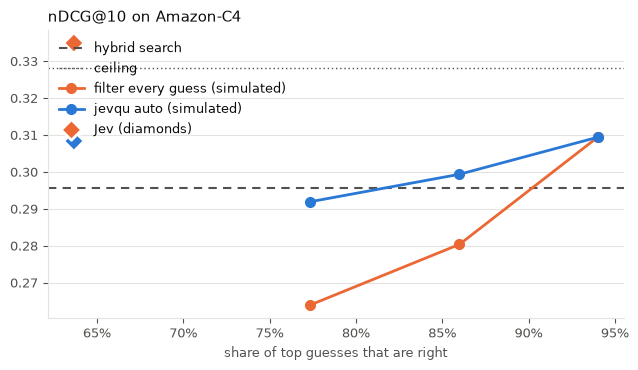

In [20]:
def measure(understood):
    return {"accuracy": np.mean([top_class(u)[0] == intent(i) for i, u in enumerate(understood)]),
            NAIVE: np.mean(scores(ranked("filter", Thresholds(filter_above=0.5), understood))[0]),
            AUTO: np.mean(scores(ranked("auto", understood=understood))[0])}

quality = []
for floor in (0.5, 0.7, 0.9):
    quality.append({"name": f"simulated, floor {floor}", **measure(understand_all(SimulatedClassifier(conf_low=floor)))})
real = {"name": f"Jev ({JEV_MODEL})", **measure(us)} if USE_JEV else None

rows = [f"| classifier | top guesses right | {BASE} | {NAIVE} | {AUTO} |", "|---|---|---|---|---|"]
rows += [f"| {q['name']} | {q['accuracy']:.0%} | {np.mean(base_ndcg):.4f} | {q[NAIVE]:.4f} | {q[AUTO]:.4f} |"
         for q in quality + ([real] if real else [])]
display(Markdown("nDCG@10 by classifier quality\n\n" + "\n".join(rows)))

ORANGE = "#eb6834"
fig, ax = plt.subplots(figsize=(6.5, 3.8))
acc = [q["accuracy"] for q in quality]
ax.axhline(np.mean(base_ndcg), color=MUTED, lw=1.5, ls=(0, (4, 3)), label=BASE)
ax.axhline(ceiling["ndcg10"], color=MUTED, lw=1, ls=(0, (1, 2)), label="ceiling")
ax.plot(acc, [q[NAIVE] for q in quality], color=ORANGE, lw=2, marker="o", ms=7, label=f"{NAIVE} (simulated)")
ax.plot(acc, [q[AUTO] for q in quality], color=BLUE, lw=2, marker="o", ms=7, label=f"{AUTO} (simulated)")
if real:
    ax.scatter([real["accuracy"]] * 2, [real[NAIVE], real[AUTO]], s=110, marker="D", color=[ORANGE, BLUE],
               edgecolor="white", linewidth=2, zorder=3, label="Jev (diamonds)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("share of top guesses that are right", color=MUTED, fontsize=9)
ax.set_title("nDCG@10 on Amazon-C4", loc="left", color=INK, fontsize=11)
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="upper left")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
fig.tight_layout()
plt.show()

## 9. Route, don't replace: Netflix's approach on the same data

Netflix's search team described their query understanding for semantic search in *From Tries to Transformers: Scaling Semantic Search* (Haystack EU 2026). Both systems put an understanding step in front of hybrid retrieval with filters and boosts, so the retrieval side compares directly:

| | Netflix | jevqu |
|---|---|---|
| Serving path | a router: trie and entity match (<10 ms), a Joint-BERT model for intents and slots (20–40 ms), an LLM only for complex natural language (100–1000 ms) | Jev on every query |
| Taxonomy | human-defined intents (FETCH, RECOMMENDATION, …) and slots (TITLE, PERSON, GENRE, …) | the catalog's departments, or induced classes kept only if filtering by them improves nDCG |
| Filter or boost | decided by the slot type (an actor becomes a filter, a synopsis term a boost) | decided by confidence, with a page refill when a filter returns too few hits |
| Labels | human seed set, an LLM as judge to scale it, a consensus gate, regular retraining | Jev's labels, checked for calibration |
| Measured by | semantic-frame accuracy offline, A/B engagement online | nDCG@10 and recall lost against relevance labels |

Netflix's advice is "keep the LLM off the hot path: use it as a judge to scale labels and let a compact model serve traffic". The same three-path router, built here:

- **fast path**: the whole query is a department name, which is how Netflix keeps its trie path to short, simple queries. A second variant acts on a department name found anywhere in the query, to show why the trie path stays narrow;
- **compact path**: a small classifier on embeddings, trained on the labels the classifier wrote into the collection. It reuses the query embedding that retrieval already computes;
- **advanced path**: the classifier itself, per query.

The router takes the fast path when the query is a department name, the compact path when its top guess has P ≥ 0.8, and the classifier otherwise.

In [21]:
def norm(s):  # lower-case words, crude singular: "Pet Supplies" -> "pet supplie"
    return " ".join(w.rstrip("s") for w in re.findall(r"[a-z0-9]+", s.lower()))

phrases = {}
for c in examples:
    for name in (c, DEPARTMENTS.get(c, c)):
        phrases.setdefault(norm(name), [(slug(c), 1.0)])

def fast_path(q, anywhere=False):  # whole query, or the longest name anywhere in it
    toks = norm(q).split()
    if not anywhere:
        hit = phrases.get(" ".join(toks))
        return Understanding(hit, {}, tax.version) if hit else None
    for n in range(min(5, len(toks)), 0, -1):
        for i in range(len(toks) - n + 1):
            hit = phrases.get(" ".join(toks[i:i + n]))
            if hit:
                return Understanding(hit, {}, tax.version)
    return None

t0 = time.perf_counter()
fast = [fast_path(q) for q in qtexts]
fast_ms = 1000 * (time.perf_counter() - t0) / len(qtexts)
fast_any = [fast_path(q, anywhere=True) for q in qtexts]
print(f"the whole query is a department name for {sum(f is not None for f in fast)} of {len(qtexts)} queries; "
      f"a department name appears somewhere in {sum(f is not None for f in fast_any)}")

the whole query is a department name for 0 of 300 queries; a department name appears somewhere in 61


In [22]:
# compact path: one small head on item embeddings, trained on the labels stored in the collection
X, y = [], []
for d, v in zip(catalog, dvecs):
    pl = stored[pid[d["item_id"]]]
    if pl.get("classes"):
        probs = pl.get("class_probs") or {}
        X.append(v); y.append(max(pl["classes"], key=probs.get))
head = LogisticRegression(max_iter=1000).fit(X, y)

def compact_path(vec):
    return Understanding([(str(c), float(p)) for c, p in zip(head.classes_, head.predict_proba([vec])[0])], {}, tax.version)

t0 = time.perf_counter()
compact = [compact_path(v) for v in qd]
predict_ms = 1000 * (time.perf_counter() - t0) / len(qd)
t0 = time.perf_counter()
for q in qtexts[:20]:
    list(dense.embed([q]))
embed_ms = 1000 * (time.perf_counter() - t0) / 20
print(f"trained on {len(y):,} labeled items ({len(set(y))} departments); {predict_ms:.2f} ms to predict "
      f"+ {embed_ms:.1f} ms to embed a query (shared with retrieval)")

trained on 19,018 labeled items (31 departments); 0.22 ms to predict + 21.2 ms to embed a query (shared with retrieval)


In [23]:
# the advanced path's live speed and price, on fresh (uncached) requests
if USE_JEV:
    with tempfile.TemporaryDirectory() as d:
        live = Jev(cache_dir=d)
        lat = []
        for q in qtexts[:20]:
            t0 = time.perf_counter()
            understand_query(client, COLLECTION, q, live)
            lat.append(1000 * (time.perf_counter() - t0))
    adv_ms, adv_usd = float(np.median(lat)), sum(live.usage) / 20
    print(f"Jev, live: median {adv_ms:.0f} ms and ${adv_usd:.6f} per query ({len(tax.level1())} questions per request)")
else:
    adv_ms = adv_usd = None
    print("Simulated classifier: no latency or price to measure. Set OPENROUTER_API_KEY to measure Jev live.")

Jev, live: median 529 ms and $0.000168 per query (31 questions per request)


In [24]:
ROUTE_CONF = 0.8
path, routed = [], []
for f, c, u in zip(fast, compact, us):
    if f is not None:
        path.append("fast"); routed.append(f)
    elif top_class(c)[1] >= ROUTE_CONF:
        path.append("compact"); routed.append(c)
    else:
        path.append("advanced"); routed.append(u)
share = {k: path.count(k) / len(path) for k in ("fast", "compact", "advanced")}

def latency(p):  # the router tries the paths in order
    ms = fast_ms + (0 if p == "fast" else embed_ms + predict_ms)
    return ms + (adv_ms or 0) if p == "advanced" else ms

ROUTER, EVERY = "Netflix-style router", f"{ADV} on every query (jevqu auto)"
strategies = {
    "fast path only": (fast, fast_ms, 0.0),
    "fast path, name anywhere in the query": (fast_any, fast_ms, 0.0),
    "compact path only": (compact, embed_ms + predict_ms, 0.0),
    EVERY: (us, adv_ms, adv_usd),
    ROUTER: (routed, float(np.mean([latency(p) for p in path])) if adv_ms else None,
             share["advanced"] * adv_usd if adv_usd is not None else None),
}
rows = ["| strategy | nDCG@10 | change (95% CI) | recall@20 | understanding latency | cost per 1k queries |",
        "|---|---|---|---|---|---|",
        f"| {BASE} | {np.mean(base_ndcg):.4f} | | {np.mean(base_rec):.4f} | 0 ms | $0 |"]
router_rows, strategy_nd = {}, {}
for name, (understood, ms, usd) in strategies.items():
    r = ranked("auto", understood=[u or Understanding([], {}, tax.version) for u in understood])
    nd_s, rc_s = scores(r)
    d, lo, hi = paired_bootstrap(base_ndcg, nd_s)
    router_rows[name], strategy_nd[name] = (d, lo, hi), nd_s
    ms_txt = f"{ms:.1f} ms" if ms is not None and ms < 10 else f"{ms:.0f} ms" if ms is not None else "n/a (simulated)"
    usd_txt = f"${1000 * usd:.3f}" if usd is not None else "n/a (simulated)"
    rows.append(f"| {name} | {np.mean(nd_s):.4f} | {d:+.4f} ({lo:+.4f} to {hi:+.4f}) | {np.mean(rc_s):.4f} | {ms_txt} | {usd_txt} |")
display(Markdown("\n".join(rows)))
print(f"router: fast path {share['fast']:.0%}, compact path {share['compact']:.0%}, {ADV} {share['advanced']:.0%} of queries")

| strategy | nDCG@10 | change (95% CI) | recall@20 | understanding latency | cost per 1k queries |
|---|---|---|---|---|---|
| hybrid search | 0.2957 | | 0.5333 | 0 ms | $0 |
| fast path only | 0.2957 | +0.0000 (+0.0000 to +0.0000) | 0.5333 | 0.1 ms | $0.000 |
| fast path, name anywhere in the query | 0.2666 | -0.0292 (-0.0470 to -0.0132) | 0.4967 | 0.1 ms | $0.000 |
| compact path only | 0.2951 | -0.0006 (-0.0048 to +0.0034) | 0.5367 | 21 ms | $0.000 |
| Jev on every query (jevqu auto) | 0.3084 | +0.0127 (+0.0048 to +0.0212) | 0.5633 | 529 ms | $0.168 |
| Netflix-style router | 0.3064 | +0.0107 (+0.0033 to +0.0189) | 0.5600 | 372 ms | $0.111 |

router: fast path 0%, compact path 34%, Jev 66% of queries


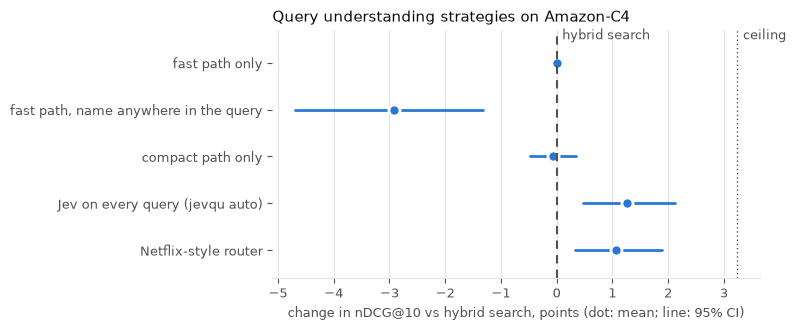

In [25]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ys = list(range(len(router_rows)))[::-1]
for y, (name, (d, lo, hi)) in zip(ys, router_rows.items()):
    ax.plot([100 * lo, 100 * hi], [y, y], color=BLUE, lw=2, solid_capstyle="round")
    ax.plot(100 * d, y, "o", color=BLUE, ms=8, markeredgecolor="white", markeredgewidth=2)
ax.axvline(0, color=MUTED, lw=1.5, ls=(0, (4, 3)))
ax.axvline(100 * gain[ORACLE], color=MUTED, lw=1, ls=(0, (1, 2)))
ax.annotate("hybrid search", (0, len(ys) - 0.5), xytext=(4, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.annotate("ceiling", (100 * gain[ORACLE], len(ys) - 0.5), xytext=(4, 0), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_yticks(ys, list(router_rows))
ax.set_ylim(-0.6, len(ys) - 0.3)
ax.set_xlabel("change in nDCG@10 vs hybrid search, points (dot: mean; line: 95% CI)", color=MUTED, fontsize=9)
ax.set_title("Query understanding strategies on Amazon-C4", loc="left", color=INK, fontsize=11)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
fig.tight_layout()
plt.show()

## 10. Two queries up close

The query jevqu helped most, and the query where filtering every guess did the most damage compared with jevqu's gating. ✓ marks the target item.

In [26]:
nd = {name: scores(r)[0] for name, r in runs.items()}
names = {pid[d["item_id"]]: title(d) for d in catalog}

def show(i, strategies):
    explain(i)
    for s in strategies:
        print(f"   {s}: nDCG@10 {nd[s][i]:.2f}")
        for p in runs[s][i][:5]:
            print("      ", "✓" if p in relevant[i] else "·", names[p][:70])
    print()

show(int(np.argmax(np.array(nd[AUTO]) - nd[BASE])), [BASE, AUTO])
show(int(np.argmax(np.array(nd[AUTO]) - nd[NAIVE])), [BASE, NAIVE, AUTO])

"I need to buy a bulk of socks for my business. I want them to be soft and of high quality. Can't wait to start using the..."
   target item's department: Clothing, Shoes and Jewelry
   P=0.97  filter  Clothing, Shoes and Jewelry
   P=0.86  boost   Amazon Fashion
   P=0.08  ignore  Health and Household
   Qdrant filter: ['clothing']
   formula boost: [('fashion', 0.0086)]
   hybrid search: nDCG@10 0.39
       · Tadge Compression Socks For Men & Women 20-30mmHg Knee High Support St
       · Medigy 3D Pop Up Greeting Cards Blank Cards for Most Occastions (Drago
       · If You Can Read This Novelty Funny Saying Crew Socks Unisex Cotton Hos
       · JUICY FRUIT 4th of July America Pop Gum (Pack of 10)
       ✓ Taiyin 80 Pairs Bulk Fuzzy Socks Gifts Fluffy Plush Winter Warm Crew S
   jevqu auto: nDCG@10 1.00
       ✓ Taiyin 80 Pairs Bulk Fuzzy Socks Gifts Fluffy Plush Winter Warm Crew S
       · Tadge Compression Socks For Men & Women 20-30mmHg Knee High Support St
       · If You Can Read

## 11. Takeaways

Generated from this run's numbers, so they hold whether the notebook ran offline or with Jev.

In [27]:
pts = lambda x: f"{100 * x:+.1f}"
ci = lambda t: f"{pts(t[0])} points (95% CI {pts(t[1])} to {pts(t[2])})"
dn, da, do = (paired_bootstrap(base_ndcg, scores(runs[k])[0]) for k in (NAIVE, AUTO, ORACLE))
base = float(np.mean(base_ndcg))
def split(name):
    idx = groups.get(name, [])
    return len(idx), (np.mean([auto_nd[i] - base_ndcg[i] for i in idx]) if idx else 0.0)
right_n, right_d = split("filter on the right department")
wrong_n, wrong_d = split("filter on a wrong department")
best = max(curve, key=lambda r: r["ndcg10"])
top = quality[-1]
dr = router_rows[ROUTER]
speed = (f", in {strategies[ROUTER][1]:.0f} ms on average instead of {strategies[EVERY][1]:.0f} ms "
         f"and ${1000 * strategies[ROUTER][2]:.3f} instead of ${1000 * adv_usd:.3f} per 1k queries") if adv_ms else ""
lines = [
    f"1. **The ceiling.** A perfect department filter adds {ci(do)} over hybrid search at {base:.2f}.",
    f"2. **The default gates** (filter at P ≥ 0.9, boost at 0.6 to 0.9) with the {ADV} add {ci(da)}, "
    f"{gain[AUTO] / gain[ORACLE]:.0%} of the ceiling. Filtering every guess adds {ci(dn)}.",
    f"3. **The threshold is a per-collection setting.** The sweep's best filter threshold is {best['threshold']}: "
    f"{pts(best['ndcg_gain'])} points, recall@20 lost {best['recall_loss']:.3f}. With it and boost_scale 0.2 "
    f"(both tuned on the evaluation queries, so optimistic): {ci(tuned_ci)}.",
    f"4. **Right filters gain, wrong ones cost.** {right_n} queries filtered on the right department changed by "
    f"{pts(right_d)} points; {wrong_n} filtered on a wrong department by {pts(wrong_d)}.",
    f"5. **Classifier quality sets how much of the ceiling is reachable.** A simulated classifier with "
    f"{top['accuracy']:.0%} of top guesses right reaches {pts(top[AUTO] - base)} points behind the default gates "
    f"({(top[AUTO] - base) / gain[ORACLE]:.0%} of the ceiling)"
    + (f"; Jev gets {real['accuracy']:.0%} right and reaches {pts(real[AUTO] - base)}." if real else "."),
    f"6. **Route, don't replace.** The Netflix-style router sent {share['fast']:.0%} of queries down the fast path, "
    f"{share['compact']:.0%} to the compact model and {share['advanced']:.0%} to the {ADV}, for {ci(dr)}{speed}.",
]
if any(fast_any):
    worst = max((i for i, f in enumerate(fast_any) if f),
                key=lambda i: base_ndcg[i] - strategy_nd["fast path, name anywhere in the query"][i])
    lines.append(f"7. **Keep the trie path narrow.** Acting on a department name found anywhere in these long queries "
                 f"changes nDCG@10 by {ci(router_rows['fast path, name anywhere in the query'])}. Worst case: "
                 f"\"{qtexts[worst][:80]}...\" was filtered to *{label_of[fast_any[worst].classes[0][0]]}*.")
display(Markdown("\n".join(lines)))

1. **The ceiling.** A perfect department filter adds +3.2 points (95% CI +1.0 to +5.5) over hybrid search at 0.30.
2. **The default gates** (filter at P ≥ 0.9, boost at 0.6 to 0.9) with the Jev add +1.3 points (95% CI +0.5 to +2.1), 39% of the ceiling. Filtering every guess adds +3.9 points (95% CI +2.2 to +5.5).
3. **The threshold is a per-collection setting.** The sweep's best filter threshold is 0.5: +3.9 points, recall@20 lost 0.000. With it and boost_scale 0.2 (both tuned on the evaluation queries, so optimistic): +3.9 points (95% CI +2.2 to +5.5).
4. **Right filters gain, wrong ones cost.** 96 queries filtered on the right department changed by +2.8 points; 59 filtered on a wrong department by +1.7.
5. **Classifier quality sets how much of the ceiling is reachable.** A simulated classifier with 94% of top guesses right reaches +1.4 points behind the default gates (42% of the ceiling); Jev gets 64% right and reaches +1.3.
6. **Route, don't replace.** The Netflix-style router sent 0% of queries down the fast path, 34% to the compact model and 66% to the Jev, for +1.1 points (95% CI +0.3 to +1.9), in 372 ms on average instead of 529 ms and $0.111 instead of $0.168 per 1k queries.
7. **Keep the trie path narrow.** Acting on a department name found anywhere in these long queries changes nDCG@10 by -2.9 points (95% CI -4.7 to -1.3). Worst case: "I need a gym mat that is durable, with a soft bottom side, and holds up well for..." was filtered to *Home and Kitchen*.

**What this does not show.** Offline, the simulated classifier stands in for Jev and picks its confidence without reading the query; rerun with `OPENROUTER_API_KEY` set for Jev's numbers. In either mode, thresholds and `boost_scale` are tuned on the evaluation queries themselves (fit them on held-out queries before shipping), the queries are machine-written with one correct item each, and relevance is offline: Netflix validated theirs with an A/B test and a holdback, which is the step after this one.

## Appendix: induce the taxonomy instead (needs an OpenRouter key and `JEVQU_INDUCE=1`)

Most collections have no clean department field. `create_query_understanding` clusters a sample of items, names candidate classes, and keeps a class only if:

- it covers between 0.5% and 40% of items (so payload-filtered search stays fast),
- enough training queries ask for it,
- it doesn't duplicate a facet, and
- filtering by it improves nDCG@10 on the queries that ask for it (bootstrap lower bound above zero).

The training queries here are C4 queries outside the evaluation set. Their target items are mostly outside the 20k-item collection, so few classes will clear the last gate; for a real induction run, build the collection around the training queries too.

In [32]:
if USE_JEV and os.environ.get("JEVQU_INDUCE"):  # opt-in: thousands of sequential Jev requests
    with open(DATA / "test.csv", newline="") as f:     # reread: `rows` was reused for table lines above
        c4_queries = list(csv.DictReader(f))
    eval_ids = {q["qid"] for q in evalq}
    train = [q for q in c4_queries if q["item_id"] in pid and q["qid"] not in eval_ids][:100]
    induced, report = create_query_understanding(
        client, COLLECTION, classifier, sample=1000, queries=[q["query"] for q in train],
        relevant=[{pid[q["item_id"]]} for q in train], embed=lambda texts: np.array(list(dense.embed(texts))))
    print(f"kept {sum(r['kept'] for r in report)} of {len(report)} candidate classes")
    for r in report[:15]:
        print(f"   {'kept' if r['kept'] else '    '}  {r['id'][:40]:40}  coverage {r['coverage']:.1%}  "
              f"demand {r['demand']}  nDCG gain {r['value'][0]:+.3f}")
else:
    print("Skipped: set OPENROUTER_API_KEY and JEVQU_INDUCE=1 to induce a taxonomy (thousands of sequential Jev requests).")

kept 0 of 40 candidate classes
         christmas-gift-holiday-santa              coverage 1.9%  demand 1  nDCG gain +0.000
         tool-cnc-machined-set                     coverage 0.0%  demand 0  nDCG gain +0.000
         women-sleeve-long-tops                    coverage 1.0%  demand 0  nDCG gain +0.000
         party-cake-each-wedding                   coverage 0.3%  demand 0  nDCG gain +0.000
         poster-lego-print-inches                  coverage 0.0%  demand 0  nDCG gain +0.000
         wireless-usb-windows-laptop               coverage 0.0%  demand 0  nDCG gain +0.000
         edition-spanish-121-futures               coverage 0.0%  demand 0  nDCG gain +0.000
         mist-oil-pack-lavender                    coverage 0.2%  demand 0  nDCG gain +0.000
         men-shoes-women-footwear                  coverage 2.8%  demand 2  nDCG gain +0.000
         measuring-laser-inch-plastic              coverage 0.2%  demand 0  nDCG gain +0.000
         1883-airforce-b00mq9a29m-b0b38